In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import itertools
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

In [ ]:
# =========================
# TCGA No IP
# =========================

DATA_PATH = "../Datasets/TCGA Dataset Splits"

X_train_TCGA = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_TCGA  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train_TCGA = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test_TCGA  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train_TCGA = np.ravel(Y_train_TCGA)
y_test_TCGA = np.ravel(Y_test_TCGA)

# =========================
# Norway No IP
# =========================
DATA_PATH = "../Datasets/Norway Dataset Splits"

X_train_Norway = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_Norway  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train_Norway = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test_Norway  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train_Norway = np.ravel(Y_train_Norway)
y_test_Norway = np.ravel(Y_test_Norway)

# =========================
# TCGA IP
# =========================
DATA_PATH = "../Datasets/TCGA InfiniumPurify Dataset Splits"

X_train_TCGA_purified = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_TCGA_purified  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train_TCGA_purified = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test_TCGA_purified  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train_TCGA_purified = np.ravel(Y_train_TCGA_purified)
y_test_TCGA_purified = np.ravel(Y_test_TCGA_purified)

# =========================
# Norway IP
# =========================
DATA_PATH = "../Datasets/Norway InfiniumPurify Dataset Splits"

X_train_Norway_purified = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_Norway_purified  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train_Norway_purified = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test_Norway_purified  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train_Norway_purified = np.ravel(Y_train_Norway_purified)
y_test_Norway_purified = np.ravel(Y_test_Norway_purified)

In [ ]:
def pick_models(model_names, model_dir):
    models = []
    for name in model_names:
        model_path = f"{model_dir}/{name}.pkl"
        model = joblib.load(model_path)
        models.append((name, model))
    return models

tcga_models = pick_models([
    "RF_TCGA_IRUS_No_RFE", "RF_TCGA_IRUS_RFE", 
    "RF_TCGA_NoImb_No_RFE", "RF_TCGA_NoImb_RFE", 
    "RF_TCGA_SMOTE_No_RFE", "RF_TCGA_SMOTE_RFE"
], "TCGA No Infinium/PKL")

norway_models = pick_models([
    "RF_Norway_IRUS_No_RFE", "RF_Norway_IRUS_RFE", 
    "RF_Norway_NoImb_No_RFE", "RF_Norway_NoImb_RFE", 
    "RF_Norway_SMOTE_No_RFE", "RF_Norway_SMOTE_RFE"
], "Norway No Infinium/PKL")

tcga_p_models = pick_models([
    "RF_TCGA_IP_IRUS_No_RFE", "RF_TCGA_IP_IRUS_RFE", 
    "RF_TCGA_IP_NoImb_No_RFE", "RF_TCGA_IP_NoImb_RFE", 
    "RF_TCGA_IP_SMOTE_No_RFE", "RF_TCGA_IP_SMOTE_RFE"
], "TCGA with InfiniumPurify/PKL")

norway_p_models = pick_models([
    "RF_Norway_IP_IRUS_No_RFE", "RF_Norway_IP_IRUS_RFE", 
    "RF_Norway_IP_NoImb_No_RFE", "RF_Norway_IP_NoImb_RFE", 
    "RF_Norway_IP_SMOTE_No_RFE", "RF_Norway_IP_SMOTE_RFE"
], "Norway with InfiniumPurify/PKL")

In [ ]:
def get_feature_names(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return None

def align_X(model, X):
    cols = get_feature_names(model)
    if cols is None:
        return X
    missing = [c for c in cols if c not in X.columns]
    if missing:
        raise ValueError(f"Missing {len(missing)} columns for model: {missing[:5]}...")
    return X.loc[:, cols]

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise ValueError("Model has no predict_proba or decision_function.")

def get_classes(model):
    if hasattr(model, "classes_"):
        return model.classes_
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "classes_"):
                return step.classes_
    raise ValueError("Model has no classes_.")

def plot_pr_curves(ax, model_entries, X_te, y_te, title):
    for name, model in model_entries:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
        ap = average_precision_score(y_bin, scores, average="micro")
        ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8, loc="lower left")


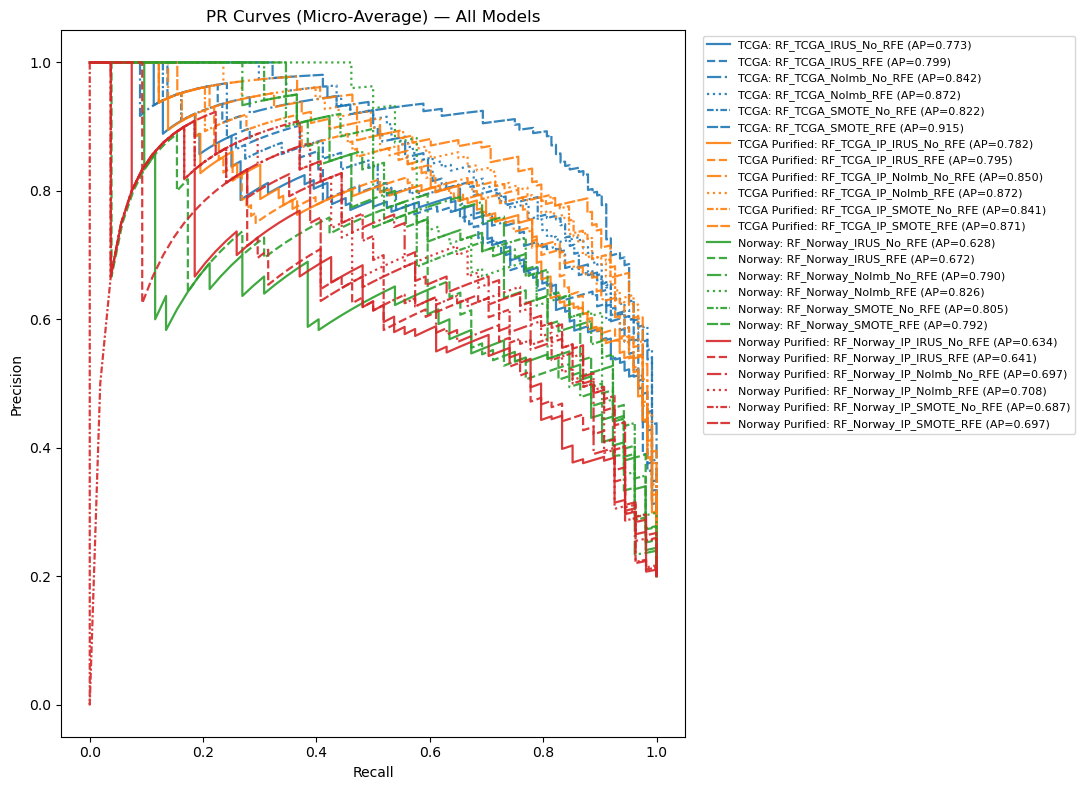

In [ ]:
def plot_group(ax, group_name, model_entries, X_te, y_te, color):
    linestyles = itertools.cycle(["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))])
    for name, model in model_entries:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
        ap = average_precision_score(y_bin, scores, average="micro")

        ax.plot(
            recall, precision,
            color=color,
            linestyle=next(linestyles),
            linewidth=1.6,
            alpha=0.9,
            label=f"{group_name}: {name} (AP={ap:.3f})"
        )

fig, ax = plt.subplots(figsize=(11, 8))

group_colors = {
    "TCGA": "tab:blue",
    "TCGA Purified": "tab:orange",
    "Norway": "tab:green",
    "Norway Purified": "tab:red",
}

groups = [
    ("TCGA", tcga_models, X_test_TCGA, y_test_TCGA),
    ("TCGA Purified", tcga_p_models, X_test_TCGA_purified, y_test_TCGA_purified),
    ("Norway", norway_models, X_test_Norway, y_test_Norway),
    ("Norway Purified", norway_p_models, X_test_Norway_purified, y_test_Norway_purified),
]

for gname, models, X_te, y_te in groups:
    plot_group(ax, gname, models, X_te, y_te, group_colors[gname])

ax.set_title("PR Curves (Micro‑Average) — All Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

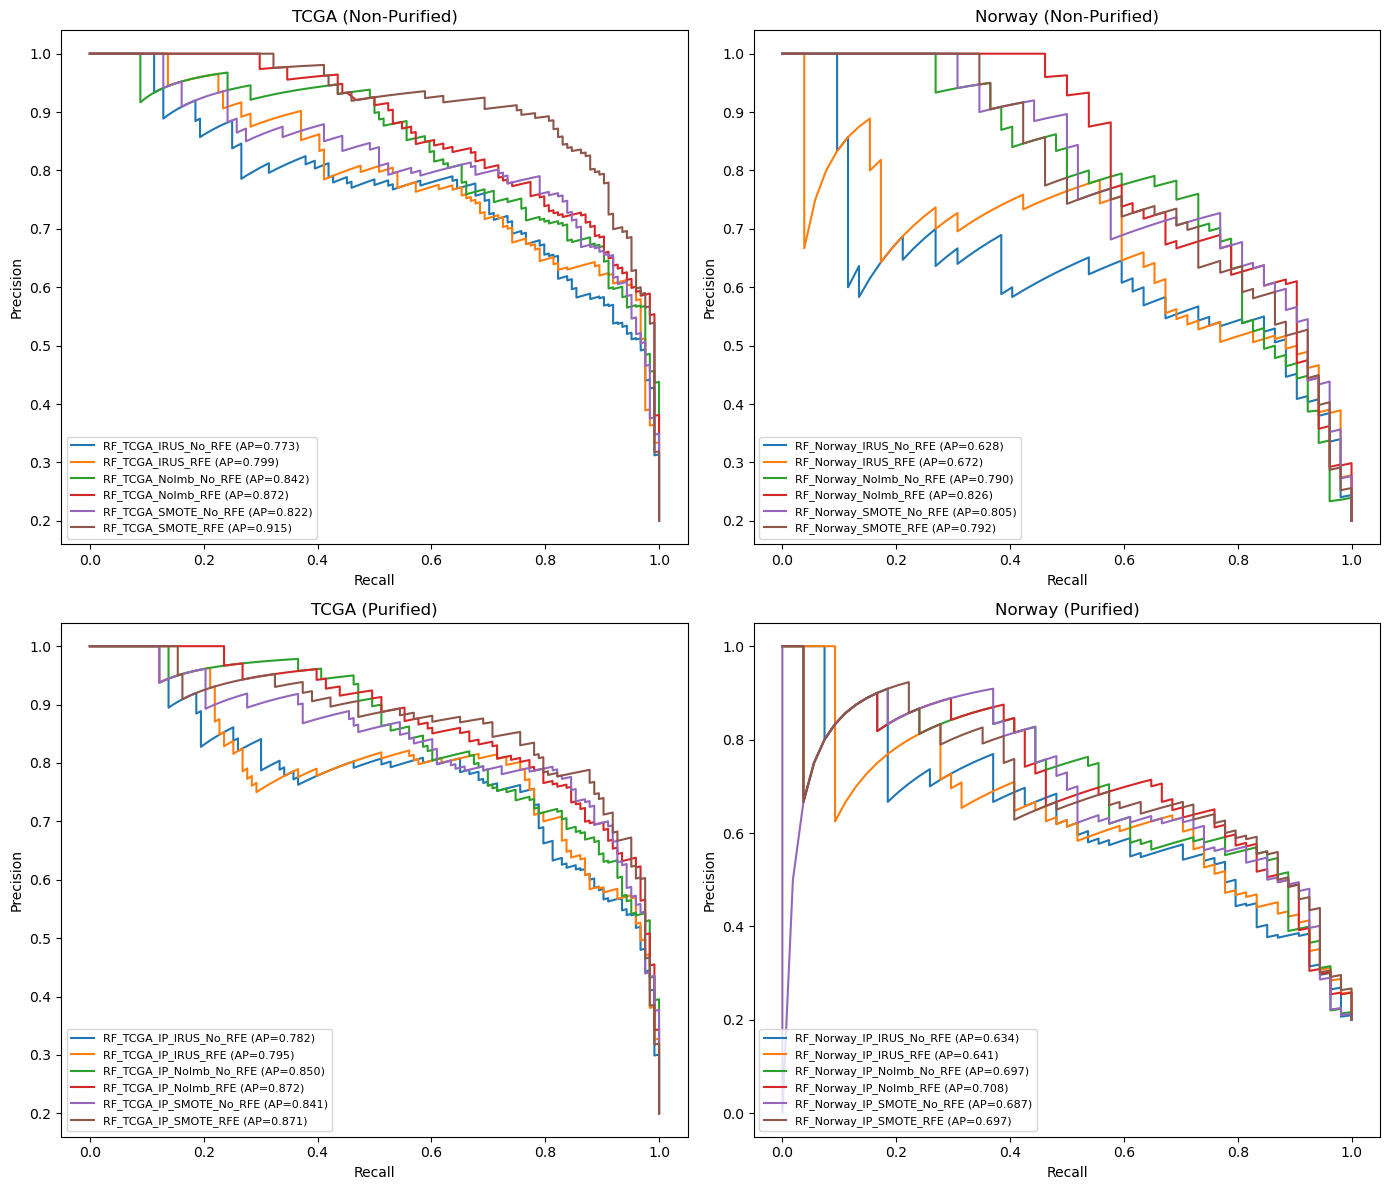

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_pr_curves(axes[0, 0], tcga_models, X_test_TCGA, y_test_TCGA, "TCGA (Non‑Purified)")
plot_pr_curves(axes[0, 1], norway_models, X_test_Norway, y_test_Norway, "Norway (Non‑Purified)")
plot_pr_curves(axes[1, 0], tcga_p_models, X_test_TCGA_purified, y_test_TCGA_purified, "TCGA (Purified)")
plot_pr_curves(axes[1, 1], norway_p_models, X_test_Norway_purified, y_test_Norway_purified, "Norway (Purified)")

plt.tight_layout()